In [5]:
from google.colab import files
uploaded = files.upload()

Saving online_retail_II.xlsx to online_retail_II (1).xlsx


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [6]:
df_2009 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_2010 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

df = pd.concat([df_2009, df_2010], ignore_index=True)

print("Dataset loaded and combined successfully!")
print(f"Combined shape: {df.shape}")
df.head()

Dataset loaded and combined successfully!
Combined shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
print("=== Shape ===")
print(df.shape)

print("\n=== Columns ===")
print(df.columns.tolist())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Info ===")
df.info()

print("\n=== Summary Statistics ===")
df.describe(include='all')


=== Shape ===
(1067371, 8)

=== Columns ===
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

=== Data Types ===
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64   

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371.0,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628.0,5305,5698,NaN,NaN,NaN,NaN,43
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1350.0,5829,5918,NaN,NaN,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504,NaN
min,NaN,NaN,NaN,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,NaN
max,NaN,NaN,NaN,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,NaN


In [8]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n=== Duplicate Rows ===")
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")
print(f"Percentage of duplicates: {(duplicate_count/len(df)*100):.2f}%")

=== Missing Values ===
             Missing Count  Missing %
Description           4382       0.41
Customer ID         243007      22.77

=== Duplicate Rows ===
Total duplicate rows: 34335
Percentage of duplicates: 3.22%


In [9]:
df['Revenue'] = df['Quantity'] * df['Price']
print("Revenue column created.")
df[['Quantity', 'Price', 'Revenue']].head()

Revenue column created.


,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


=== Top 10 Products by Quantity Sold ===
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     108545
WHITE HANGING HEART T-LIGHT HOLDER     93050
ASSORTED COLOUR BIRD ORNAMENT          81306
JUMBO BAG RED RETROSPOT                78090
BROCADE RING PURSE                     70700
PACK OF 60 PINK PAISLEY CAKE CASES     56575
60 TEATIME FAIRY CAKE CASES            54366
SMALL POPCORN HOLDER                   49616
PACK OF 72 RETROSPOT CAKE CASES        49344
PACK OF 72 RETRO SPOT CAKE CASES       46106
Name: Quantity, dtype: int64

=== Top 10 Products by Revenue ===
Description
REGENCY CAKESTAND 3 TIER               327813.65
DOTCOM POSTAGE                         322647.47
WHITE HANGING HEART T-LIGHT HOLDER     257533.90
JUMBO BAG RED RETROSPOT                148800.64
PARTY BUNTING                          147948.50
ASSORTED COLOUR BIRD ORNAMENT          131413.85
PAPER CHAIN KIT 50'S CHRISTMAS         121662.14
POSTAGE                                112341.00
CHILLI LIGHTS               

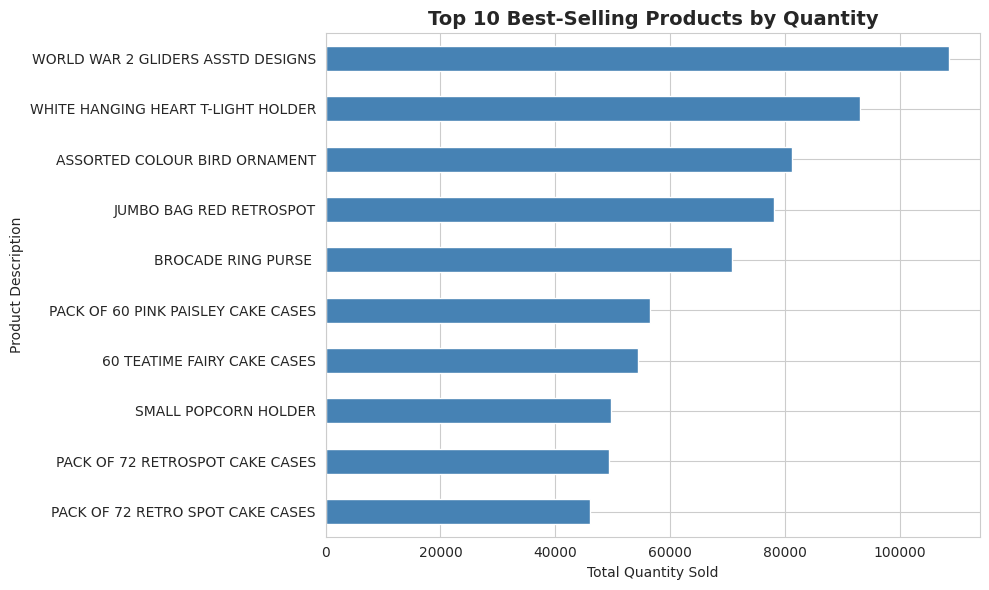

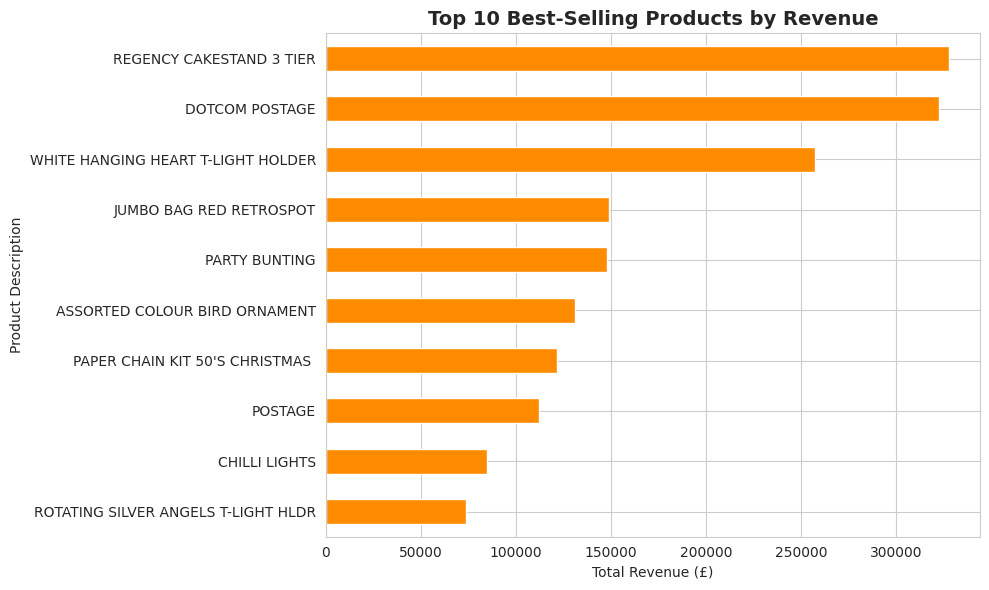

In [10]:
#Top 10 best-selling products (by Quantity and by Revenue)
# Top 10 by Quantity
top10_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("=== Top 10 Products by Quantity Sold ===")
print(top10_qty)

# Top 10 by Revenue
top10_rev = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
print("\n=== Top 10 Products by Revenue ===")
print(top10_rev)

# Visualize - Quantity
plt.figure(figsize=(10,6))
top10_qty.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Best-Selling Products by Quantity', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

# Visualize - Revenue
plt.figure(figsize=(10,6))
top10_rev.sort_values().plot(kind='barh', color='darkorange')
plt.title('Top 10 Best-Selling Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

=== Top 10 Countries by Revenue ===
Country
United Kingdom    1.638258e+07
EIRE              6.155196e+05
Netherlands       5.485249e+05
Germany           4.179886e+05
France            3.281918e+05
Australia         1.671291e+05
Switzerland       9.972876e+04
Spain             9.185948e+04
Sweden            8.780942e+04
Denmark           6.574109e+04
Name: Revenue, dtype: float64


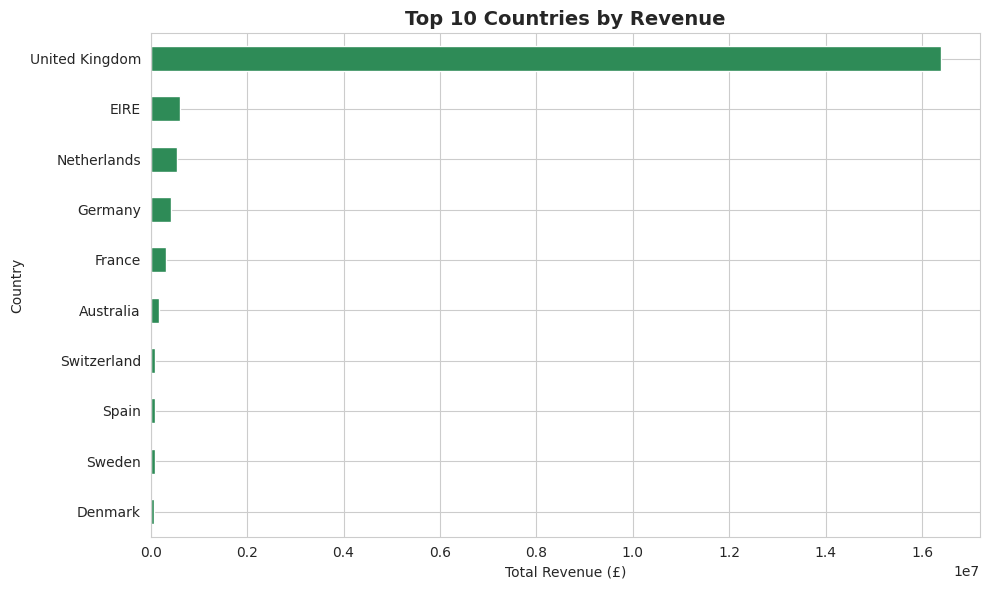

In [12]:
#Sales performance by country
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
print("=== Top 10 Countries by Revenue ===")
print(country_sales)

plt.figure(figsize=(10,6))
country_sales.sort_values().plot(kind='barh', color='seagreen')
plt.title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

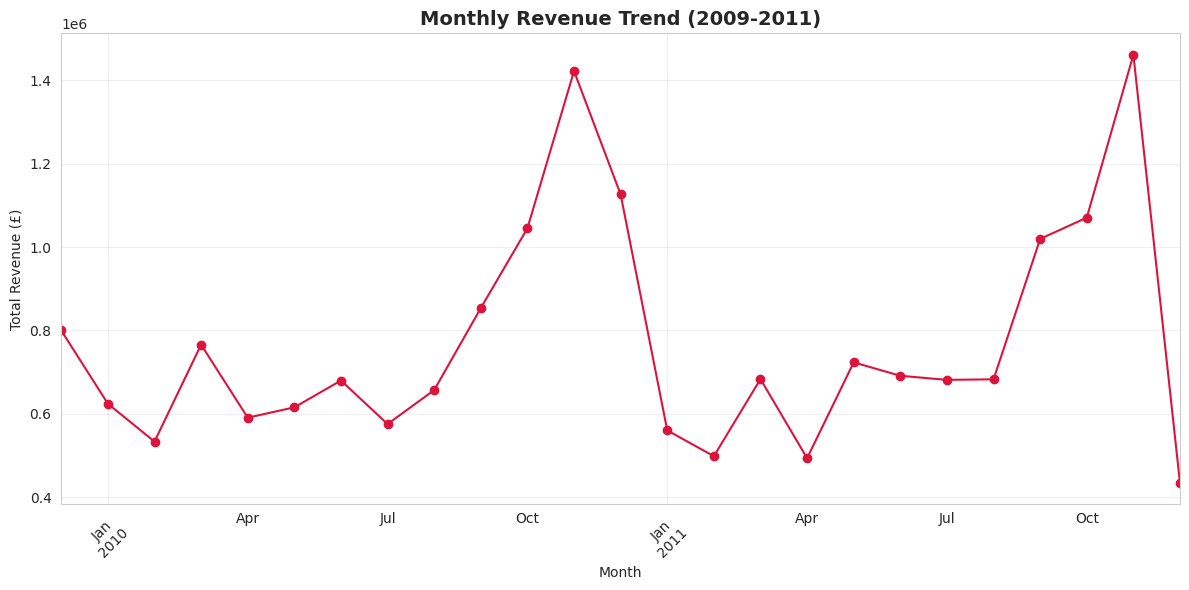

In [13]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('InvoiceMonth')['Revenue'].sum()

plt.figure(figsize=(12,6))
monthly_revenue.plot(kind='line', marker='o', color='crimson')
plt.title('Monthly Revenue Trend (2009-2011)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

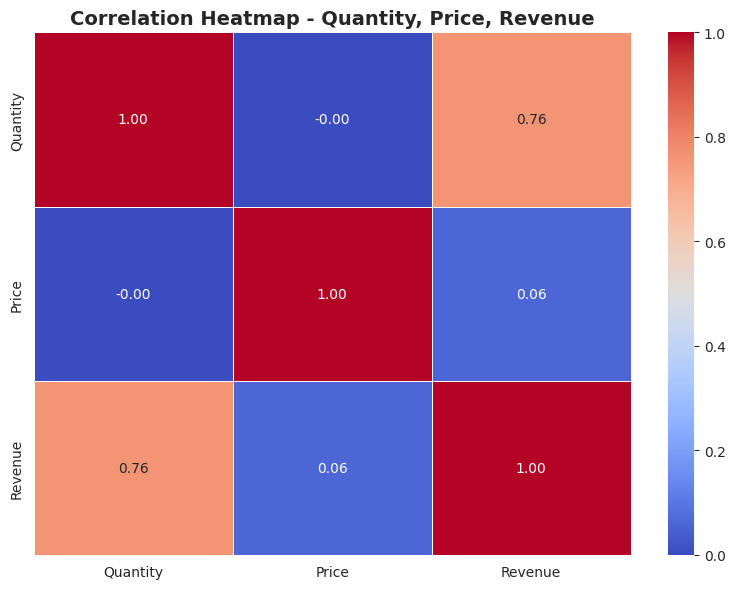

In [14]:
#Correlation heatmap
# Select numeric columns for correlation
numeric_cols = df[['Quantity', 'Price', 'Revenue']]

plt.figure(figsize=(8,6))
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Quantity, Price, Revenue', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

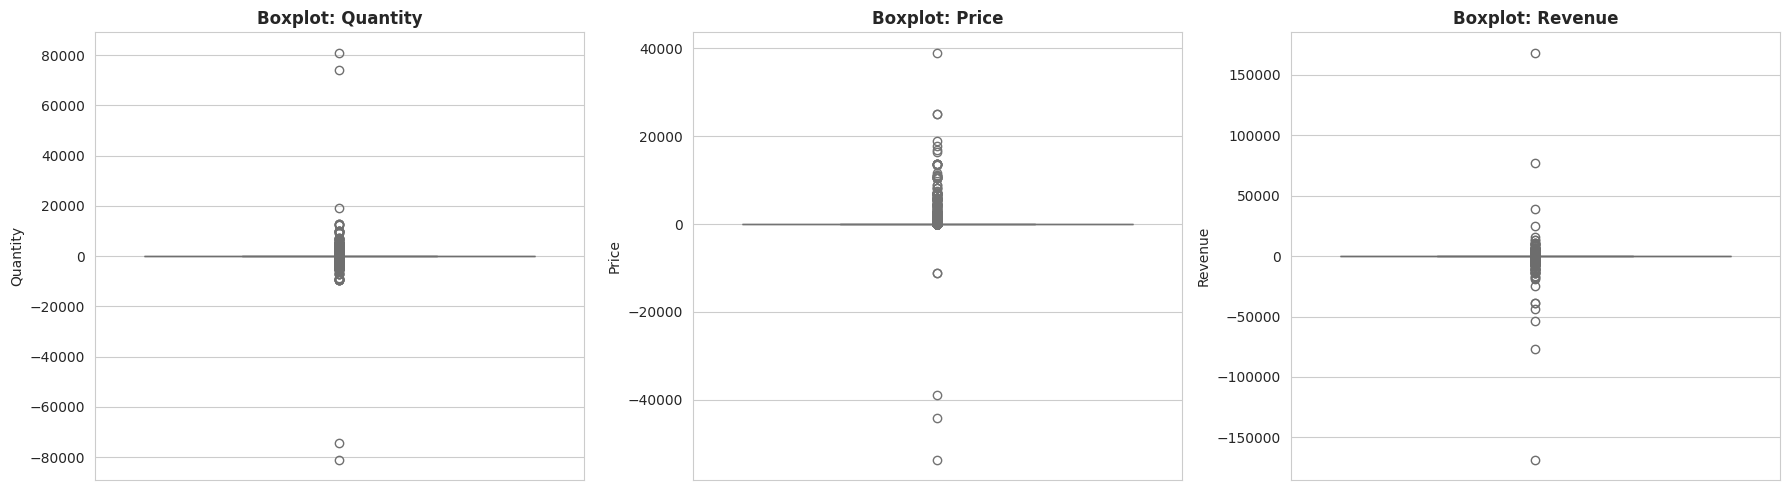

Quantity: 116489 outliers detected (10.91%)
Price: 68105 outliers detected (6.38%)
Revenue: 90922 outliers detected (8.52%)


In [15]:
#Outlier detection with box plots
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(y=df['Quantity'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot: Quantity', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Quantity')

sns.boxplot(y=df['Price'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot: Price', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price')

sns.boxplot(y=df['Revenue'], ax=axes[2], color='salmon')
axes[2].set_title('Boxplot: Revenue', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Revenue')

plt.tight_layout()
plt.show()

# Quantify outliers using IQR method
for col in ['Quantity', 'Price', 'Revenue']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers detected ({(len(outliers)/len(df)*100):.2f}%)")

In [16]:
print("Notebook executed successfully from top to bottom with no errors ✅")
print(f"Final dataset shape: {df.shape}")

Notebook executed successfully from top to bottom with no errors ✅
Final dataset shape: (1067371, 10)


In [17]:
#Business Insights
"""
1. Revenue is heavily concentrated in one market
The United Kingdom contributes roughly  84.94% of total revenue, showing strong dependence on a single country.
The business should consider expanding marketing in the next-highest revenue countries (e.g., Germany, EIRE, France)
to diversify and reduce geographic risk.
2. A small set of products drives a large share of revenue
The top 10 best-selling products account for a disproportionately large share of total revenue relative to the size
of the full product catalog. Prioritizing stock availability and promotion for these high performers could improve
overall sales efficiency.
3. Sales show a clear seasonal pattern
Monthly revenue rises sharply toward [November–December], indicating strong holiday-driven demand. The company should
plan inventory, staffing, and marketing campaigns in advance of this peak season each year.
4. Missing customer data limits personalization potential
About 22.77% of transactions have no Customer ID, meaning a significant portion of sales cannot be linked to a specific
customer. This is a key data-quality gap that must be addressed before building a reliable recommendation system.
5. Negative quantities reflect returns, not data errors
A portion of records show negative Quantity values, corresponding to cancelled orders (Invoice numbers starting with "C").
These represent real returns/cancellations and should be treated as a separate category in future analysis rather than
treated as noise or removed.
"""

'\n1. Revenue is heavily concentrated in one market\nThe United Kingdom contributes roughly  84.94% of total revenue, showing strong dependence on a single country. \nThe business should consider expanding marketing in the next-highest revenue countries (e.g., Germany, EIRE, France) \nto diversify and reduce geographic risk.\n2. A small set of products drives a large share of revenue\nThe top 10 best-selling products account for a disproportionately large share of total revenue relative to the size \nof the full product catalog. Prioritizing stock availability and promotion for these high performers could improve \noverall sales efficiency.\n3. Sales show a clear seasonal pattern\nMonthly revenue rises sharply toward [November–December], indicating strong holiday-driven demand. The company should \nplan inventory, staffing, and marketing campaigns in advance of this peak season each year.\n4. Missing customer data limits personalization potential\nAbout 22.77% of transactions have no C